# 02. 다중회귀 분석과 Trade-off 구조

1차 DOE 27 runs 데이터로 반응별 1차 회귀 모델을 적합하고,
계수가 ground truth를 잘 복원하는지, 그리고 Bias를 둘러싼 상충 구조를 정량적으로 확인한다.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config import RANDOM_SEED, SECOND_DOE_CHF3, TRUE_COEF, SPECS
from src.data_gen import simulate_experiment, simulate_replicates
from src.doe_design import first_doe, second_doe
from src.analysis import (fit_all, fit_ols, ols_report, predict,
                          standardized_effects)
from src.optimization import (best_condition, desirability, grid_search,
                              validation_table)
from src.spc import monitoring_run, reproducibility_report
from src.visualization import (desirability_contour, effect_magnitude_plot,
                               i_chart_panel, main_effects_plot,
                               tradeoff_plot)

pd.set_option("display.width", 120)


In [2]:
doe1 = simulate_experiment(first_doe(), seed=RANDOM_SEED)  # 01과 동일 시드 → 동일 데이터
report = ols_report(doe1, ["ER", "UT", "MD", "THETA"])
report

,response,term,coef,p_value,r_squared
0,ER,const,202.4852,2.070000e-18,0.9890
1,ER,CHF3,-2.8175,5.060000e-13,0.9890
2,ER,P,-1.2623,9.280000e-16,0.9890
3,ER,B,2.5077,2.100000e-22,0.9890
4,UT,const,4.9019,4.790000e-17,0.9915
5,UT,CHF3,-0.1470,6.410000e-19,0.9915
6,UT,P,0.0777,1.940000e-23,0.9915
7,UT,B,-0.0192,2.700000e-10,0.9915
8,MD,const,-7.4495,7.180000e-21,0.9953
9,MD,CHF3,0.0293,2.520000e-05,0.9953


## 적합 결과 해석

- 모든 반응에서 **R² > 0.98** — 1차(선형) 모델로 충분히 설명된다.
- THETA에 대한 Bias 계수만 p-value가 크다(참값 자체가 0) — 통계적으로도 올바르게 "효과 없음"으로 나온다.

## 추정 계수 vs. 참값(ground truth)

시뮬레이션 프로젝트의 장점: 정답을 알고 있으므로 분석 파이프라인 자체를 검증할 수 있다.

In [3]:
rows = []
for r in ["ER", "UT", "MD"]:
    m = fit_ols(doe1, r)
    for term in ["const", "CHF3", "P", "B"]:
        rows.append({"response": r, "term": term,
                     "true": TRUE_COEF[r]["const" if term == "const" else term],
                     "estimated": round(float(m.params[term]), 4),
                     "std_err": round(float(m.bse[term]), 4)})
comp = pd.DataFrame(rows)
comp["within_2se"] = (comp["true"] - comp["estimated"]).abs() <= 2 * comp["std_err"]
comp

,response,term,true,estimated,std_err,within_2se
0,ER,const,206.00,202.4852,7.9051,True
1,ER,CHF3,-3.00,-2.8175,0.1951,True
2,ER,P,-1.20,-1.2623,0.0650,True
3,ER,B,2.50,2.5077,0.0650,True
4,UT,const,4.95,4.9019,0.2206,True
5,UT,CHF3,-0.15,-0.1470,0.0054,True
6,UT,P,0.08,0.0777,0.0018,True
7,UT,B,-0.02,-0.0192,0.0018,True
8,MD,const,-7.55,-7.4495,0.2259,True
9,MD,CHF3,0.03,0.0293,0.0056,True


대부분의 계수가 ±2SE 안에서 참값을 복원한다 (27 runs, 노이즈 존재 조건에서 기대되는 수준).

## Bias Power를 둘러싼 상충 구조

- **ER 스펙**: ≥ 300 nm/min → Bias를 **올려야** 함 (+2.5 nm/min per W)
- **M/D 스펙**: ≤ 3 % → Bias를 **내려야** 함 (+0.12 %p per W)

같은 노브에 반대 방향의 요구가 걸려 있으므로 단일 반응 최적화로는 답이 없다.

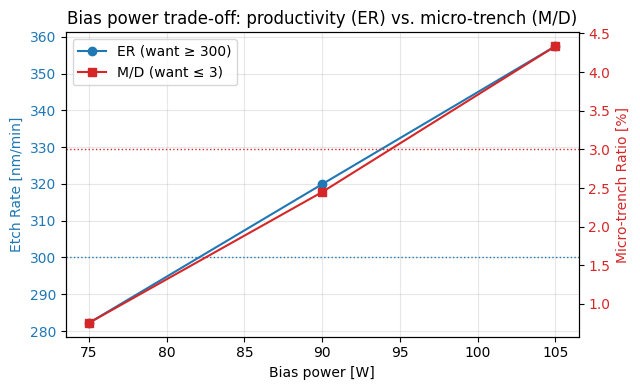

In [4]:
fig = tradeoff_plot(doe1)
plt.show()

## 결론

Bias 한 인자만으로는 ER과 M/D를 동시에 만족시킬 수 없고,
Pressure(U/T 지배)까지 얽혀 있으므로 **4개 반응을 하나의 목적함수로 묶는
Desirability 기반 다중 반응 동시 최적화**가 필요하다. → 03 노트북.